# Análisis Detallado: Función Rosenbrock 2D

Este notebook realiza un análisis exhaustivo de la aproximación de la función Rosenbrock usando MLP y KAN con diferentes optimizadores.

## Objetivos:
- Comparar MLP vs KAN en la función Rosenbrock
- Evaluar diferentes optimizadores (Adam, LBFGS, Adam+LBFGS)
- Análisis detallado de convergencia y métricas
- Visualizaciones comparativas de aproximaciones
- Análisis de errores y distribución


In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import sys
import time
from datetime import datetime

# Agregar el directorio raíz al path
sys.path.insert(0, os.path.abspath('..'))

# Imports del proyecto
from src.data import FUNCTION_REGISTRY, make_function_dataset
from src.wrappers import build_model, run_single_experiment
from src.config import MLP_CONFIG, KAN_CONFIG
from src.eval import compute_error_metrics
import models.optimizers as optimizers

# Configuración de matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


## Configuración del Experimento

Configuramos parámetros específicos para un análisis detallado:
- Más muestras de datos
- Arquitecturas más grandes
- Más iteraciones
- Criterios de parada más estrictos


In [4]:
# Función a analizar
FUNC_NAME = "rosenbrock_2d"

# Configuración de dataset (más muestras para análisis detallado)
dataset_cfg = {
    "n_samples": 2000,
    "noise_std": 0.01,
    "test_ratio": 0.2,
    "seed_data": 42,
}

# Configuración de MLP (arquitectura más grande)
mlp_cfg = {
    "hidden_width": 64,
    "hidden_layers": 3,
    "activation": "tanh",
    "seed_model": 42,
}

# Configuración de KAN (grilla más fina)
kan_cfg = {
    "n_grid_x_2d": 16,
    "n_grid_y_2d": 16,
    "n_hidden_2d": 32,
    "seed_model": 42,
}

# Configuración detallada de optimizadores (más iteraciones)
detailed_opt_config = {
    "adam": {
        "lr": 5e-3,
        "max_iters": 2000,  # Muchas más iteraciones
    },
    "lbfgs": {
        "lr": 1.0,
        "max_iters": 1000,  # Más iteraciones para LBFGS
        "m_history": 20,  # Más memoria para mejor convergencia
    },
    "adam_lbfgs": {
        "lr_adam": 5e-3,
        "iters_adam": 1000,  # Más pasos de Adam
        "lr_lbfgs": 1.0,
        "iters_lbfgs": 500,  # Más pasos de LBFGS
        "m_history": 20,
    },
}

# Optimizadores a probar
OPTIMIZERS_TO_TEST = ["adam", "lbfgs", "adam_lbfgs"]

print("Configuración del experimento:")
print(f"  Función: {FUNC_NAME}")
print(f"  Muestras: {dataset_cfg['n_samples']}")
print(f"  MLP: {mlp_cfg['hidden_layers']} capas, {mlp_cfg['hidden_width']} neuronas")
print(f"  KAN: Grid {kan_cfg['n_grid_x_2d']}x{kan_cfg['n_grid_y_2d']}, {kan_cfg['n_hidden_2d']} nodos ocultos")
print(f"  Optimizadores: {', '.join(OPTIMIZERS_TO_TEST)}")


Configuración del experimento:
  Función: rosenbrock_2d
  Muestras: 2000
  MLP: 3 capas, 64 neuronas
  KAN: Grid 16x16, 32 nodos ocultos
  Optimizadores: adam, lbfgs, adam_lbfgs


## Generación del Dataset


In [5]:
# Generar dataset
X_train, y_train, X_test, y_test, func_cfg = make_function_dataset(
    FUNC_NAME,
    n_samples=dataset_cfg["n_samples"],
    noise_std=dataset_cfg["noise_std"],
    test_ratio=dataset_cfg["test_ratio"],
    seed=dataset_cfg["seed_data"],
)

print(f"Dataset generado:")
print(f"  Entrenamiento: {X_train.shape[0]} muestras")
print(f"  Prueba: {X_test.shape[0]} muestras")
print(f"  Dominio: {func_cfg['domain']}")
print(f"  Rango de salida: [{y_train.min():.2f}, {y_train.max():.2f}]")


Dataset generado:
  Entrenamiento: 1600 muestras
  Prueba: 400 muestras
  Dominio: ((-1.5, 1.5), (-0.5, 3.0))
  Rango de salida: [0.07, 893.12]


## Visualización de la Función Rosenbrock

La función Rosenbrock es una función de prueba clásica con un valle largo y estrecho que hace difícil la optimización.


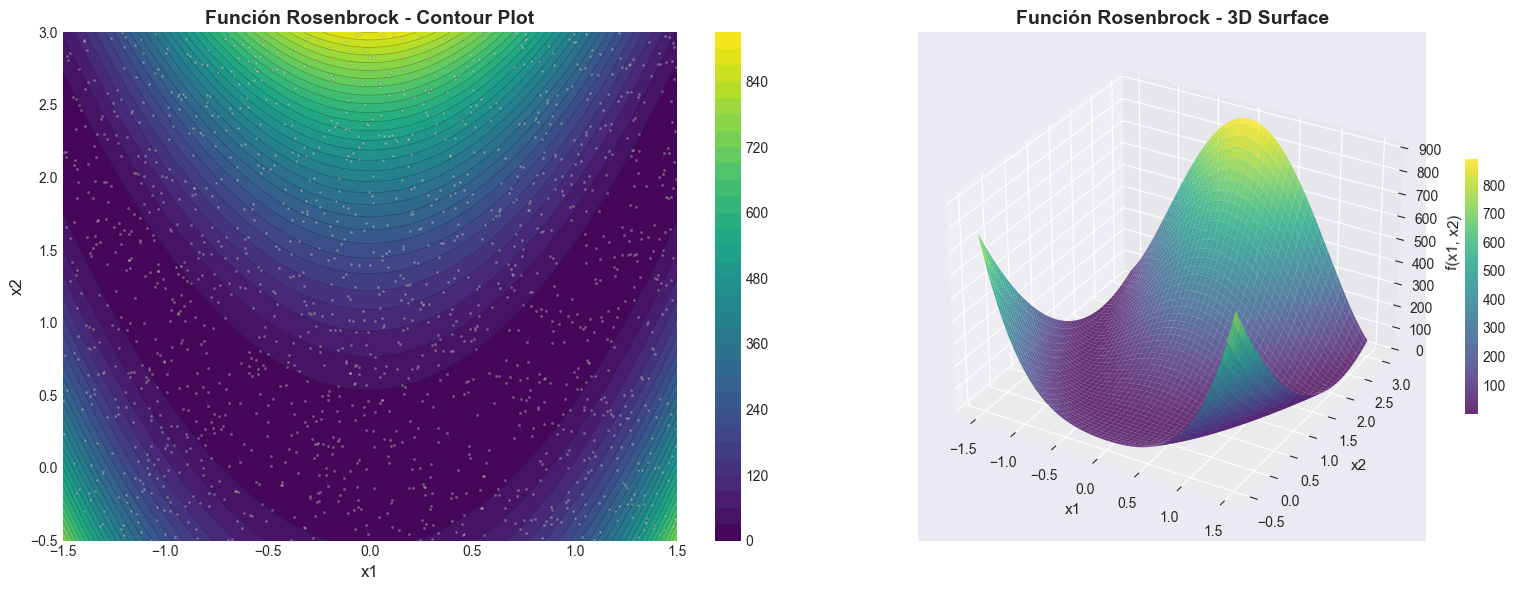


Características de la función:
  Mínimo global: f(1, 1) = 0
  Valle largo y estrecho que dificulta la optimización
  Gradientes pequeños en el valle


In [6]:
# Obtener función verdadera
fn_true = func_cfg['fn']
(x1_min, x1_max), (x2_min, x2_max) = func_cfg['domain']

# Crear grilla para visualización
n_grid = 100
x1 = np.linspace(x1_min, x1_max, n_grid)
x2 = np.linspace(x2_min, x2_max, n_grid)
X1g, X2g = np.meshgrid(x1, x2, indexing='xy')
X_flat = np.stack([X1g.ravel(), X2g.ravel()], axis=1)
y_true_grid = fn_true(X_flat).reshape(X1g.shape)

# Visualización
fig = plt.figure(figsize=(16, 6))

# Contour plot
ax1 = fig.add_subplot(121)
cs1 = ax1.contourf(X1g, X2g, y_true_grid, levels=30, cmap='viridis')
ax1.contour(X1g, X2g, y_true_grid, levels=30, colors='black', alpha=0.3, linewidths=0.5)
ax1.scatter(X_train[:, 0], X_train[:, 1], s=5, alpha=0.3, c='white', edgecolors='k', linewidths=0.3)
ax1.set_xlabel('x1', fontsize=12)
ax1.set_ylabel('x2', fontsize=12)
ax1.set_title('Función Rosenbrock - Contour Plot', fontsize=14, fontweight='bold')
plt.colorbar(cs1, ax=ax1)

# 3D Surface plot
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X1g, X2g, y_true_grid, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax2.set_xlabel('x1', fontsize=11)
ax2.set_ylabel('x2', fontsize=11)
ax2.set_zlabel('f(x1, x2)', fontsize=11)
ax2.set_title('Función Rosenbrock - 3D Surface', fontsize=14, fontweight='bold')
fig.colorbar(surf, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

print(f"\nCaracterísticas de la función:")
print(f"  Mínimo global: f(1, 1) = 0")
print(f"  Valle largo y estrecho que dificulta la optimización")
print(f"  Gradientes pequeños en el valle")


## Ejecución de Experimentos

Ejecutamos experimentos para MLP y KAN con cada optimizador, capturando métricas detalladas y historiales de pérdida.


In [7]:
# Almacenar resultados
results = {}
loss_histories = {}

print("="*80)
print("EJECUTANDO EXPERIMENTOS")
print("="*80)

for model_type in ["mlp", "kan"]:
    results[model_type] = {}
    loss_histories[model_type] = {}
    
    for opt_name in OPTIMIZERS_TO_TEST:
        exp_id = f"{FUNC_NAME}__{model_type}__{opt_name}"
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] {exp_id}")
        
        opt_cfg = detailed_opt_config[opt_name]
        
        start_time = time.time()
        
        try:
            res = run_single_experiment(
                func_name=FUNC_NAME,
                model_type=model_type,
                optimizer_name=opt_name,
                dataset_cfg=dataset_cfg,
                mlp_cfg=mlp_cfg,
                kan_cfg=kan_cfg,
                opt_cfg=opt_cfg,
                verbose=True,  # Mostrar progreso
            )
            
            elapsed_time = time.time() - start_time
            res['train_time_sec'] = elapsed_time
            
            results[model_type][opt_name] = res
            loss_histories[model_type][opt_name] = res['history']
            
            print(f"  ✓ Test RMSE: {res['test_metrics']['rmse']:.6e}")
            print(f"  ✓ GradNorm: {res['grad_norm']:.6e}")
            print(f"  ✓ Iteraciones: {res['n_steps']}")
            print(f"  ✓ Tiempo: {elapsed_time:.2f}s")
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
            import traceback
            traceback.print_exc()

print("\n" + "="*80)
print("EXPERIMENTOS COMPLETADOS")
print("="*80)


EJECUTANDO EXPERIMENTOS

[00:06:32] rosenbrock_2d__mlp__adam
ADAM iter 1/2000  loss=6.724708e+04
ADAM iter 200/2000  loss=4.871543e+04
ADAM iter 400/2000  loss=4.183603e+04
ADAM iter 600/2000  loss=3.951057e+04
ADAM iter 800/2000  loss=3.893731e+04
ADAM iter 1000/2000  loss=3.883905e+04
ADAM iter 1200/2000  loss=3.882753e+04
ADAM iter 1400/2000  loss=2.141879e+04
ADAM iter 1600/2000  loss=1.457980e+04
ADAM iter 1800/2000  loss=1.046780e+04
ADAM iter 2000/2000  loss=7.723416e+03
  ✓ Test RMSE: 8.644665e+01
  ✓ GradNorm: 4.483355e+02
  ✓ Iteraciones: 2000
  ✓ Tiempo: 15.35s

[00:06:48] rosenbrock_2d__mlp__lbfgs
LBFGS iter 1/1000  loss=4.023292e+04
Early stopping: no improvement for 10 iterations at iter 62
  ✓ Test RMSE: 1.969618e+02
  ✓ GradNorm: 1.573734e+03
  ✓ Iteraciones: 62
  ✓ Tiempo: 1.11s

[00:06:49] rosenbrock_2d__mlp__adam_lbfgs
ADAM iter 1/1000  loss=6.724708e+04
ADAM iter 100/1000  loss=5.524680e+04
ADAM iter 200/1000  loss=4.871543e+04
ADAM iter 300/1000  loss=4.446335e+04


| train_loss: 4.94e+00 | test_loss: 7.43e+00 | reg: 2.19e+04 | : 100%|█| 2000/2000 [03:28<00:00,  9.


saving model version 0.1
  ✓ Test RMSE: 7.432656e+00
  ✓ GradNorm: 2.755767e+01
  ✓ Iteraciones: 2000
  ✓ Tiempo: 208.98s

[00:10:28] rosenbrock_2d__kan__lbfgs
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.72e-02 | test_loss: 6.60e-01 | reg: 3.56e+02 | : 100%|█| 1000/1000 [21:26<00:00,  1.


saving model version 0.1
  ✓ Test RMSE: 6.600240e-01
  ✓ GradNorm: 5.893421e-03
  ✓ Iteraciones: 1000
  ✓ Tiempo: 1286.73s

[00:31:55] rosenbrock_2d__kan__adam_lbfgs
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.17e-02 | test_loss: 8.05e-01 | reg: 3.58e+02 | : 100%|█| 1500/1500 [13:05<00:00,  1.

saving model version 0.1
  ✓ Test RMSE: 8.051089e-01
  ✓ GradNorm: 4.498453e-03
  ✓ Iteraciones: 1500
  ✓ Tiempo: 785.73s

EXPERIMENTOS COMPLETADOS


## Comparación de Curvas de Pérdida - Todos los Optimizadores

Visualizamos la evolución de la pérdida para cada modelo y optimizador.


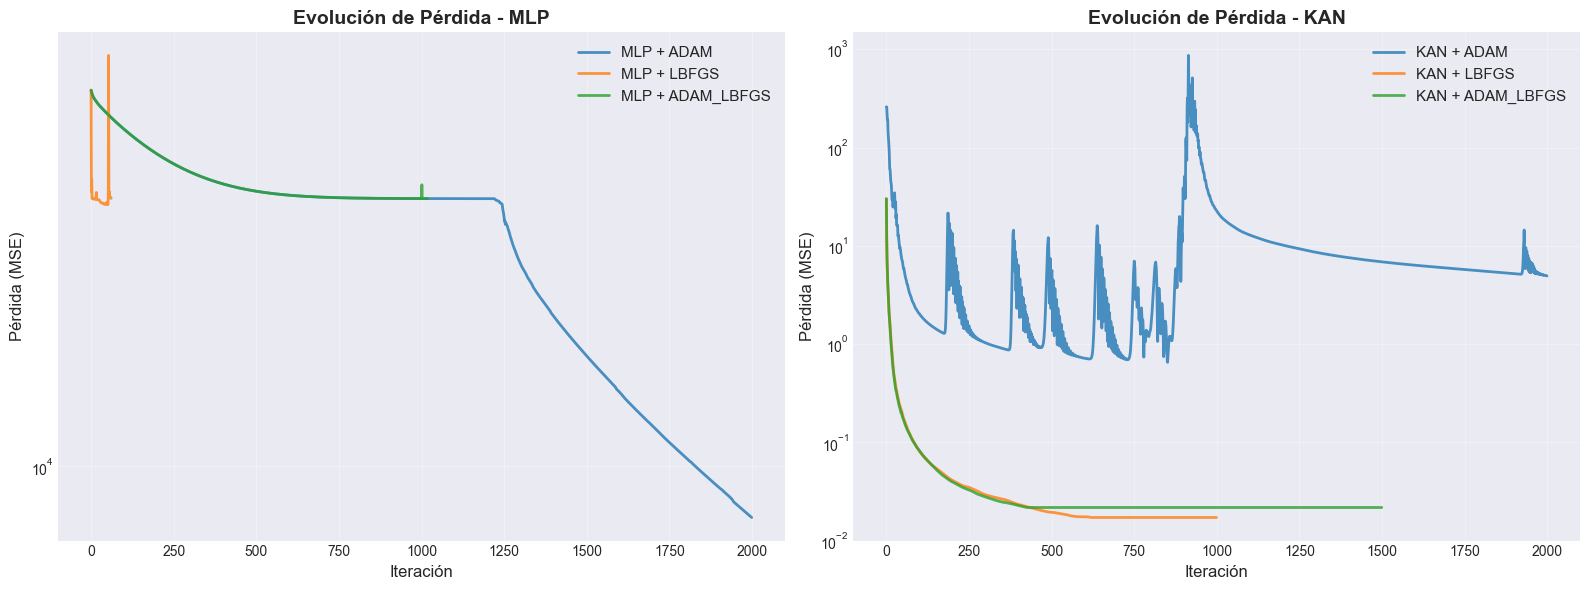

In [8]:
# Gráfico para MLP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MLP
ax1 = axes[0]
for opt_name in OPTIMIZERS_TO_TEST:
    if opt_name in loss_histories['mlp']:
        history = loss_histories['mlp'][opt_name]
        if len(history) > 0:
            ax1.plot(history, label=f"MLP + {opt_name.upper()}", linewidth=2, alpha=0.8)

ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Pérdida (MSE)', fontsize=12)
ax1.set_title('Evolución de Pérdida - MLP', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# KAN
ax2 = axes[1]
for opt_name in OPTIMIZERS_TO_TEST:
    if opt_name in loss_histories['kan']:
        history = loss_histories['kan'][opt_name]
        if len(history) > 0:
            ax2.plot(history, label=f"KAN + {opt_name.upper()}", linewidth=2, alpha=0.8)

ax2.set_xlabel('Iteración', fontsize=12)
ax2.set_ylabel('Pérdida (MSE)', fontsize=12)
ax2.set_title('Evolución de Pérdida - KAN', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Identificación del Mejor Optimizador

Identificamos el mejor optimizador para cada modelo basado en el RMSE de prueba.


In [9]:
# Encontrar mejor optimizador para cada modelo
best_optimizers = {}

for model_type in ["mlp", "kan"]:
    best_opt = None
    best_rmse = float('inf')
    
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results[model_type]:
            rmse = results[model_type][opt_name]['test_metrics']['rmse']
            if rmse < best_rmse:
                best_rmse = rmse
                best_opt = opt_name
    
    if best_opt:
        best_optimizers[model_type] = {
            'optimizer': best_opt,
            'rmse': best_rmse,
            'result': results[model_type][best_opt]
        }
        print(f"{model_type.upper()}: Mejor optimizador = {best_opt.upper()}")
        print(f"  Test RMSE: {best_rmse:.6e}")
        print(f"  Test MAE: {results[model_type][best_opt]['test_metrics']['mae']:.6e}")
        print(f"  GradNorm: {results[model_type][best_opt]['grad_norm']:.6e}")
        print()


MLP: Mejor optimizador = ADAM
  Test RMSE: 8.644665e+01
  Test MAE: 2.998680e+01
  GradNorm: 4.483355e+02

KAN: Mejor optimizador = LBFGS
  Test RMSE: 6.600240e-01
  Test MAE: 2.038276e-01
  GradNorm: 5.893421e-03



## Comparación de Mejores Modelos

Comparamos la evolución de pérdida de los mejores modelos (MLP y KAN con sus respectivos mejores optimizadores).


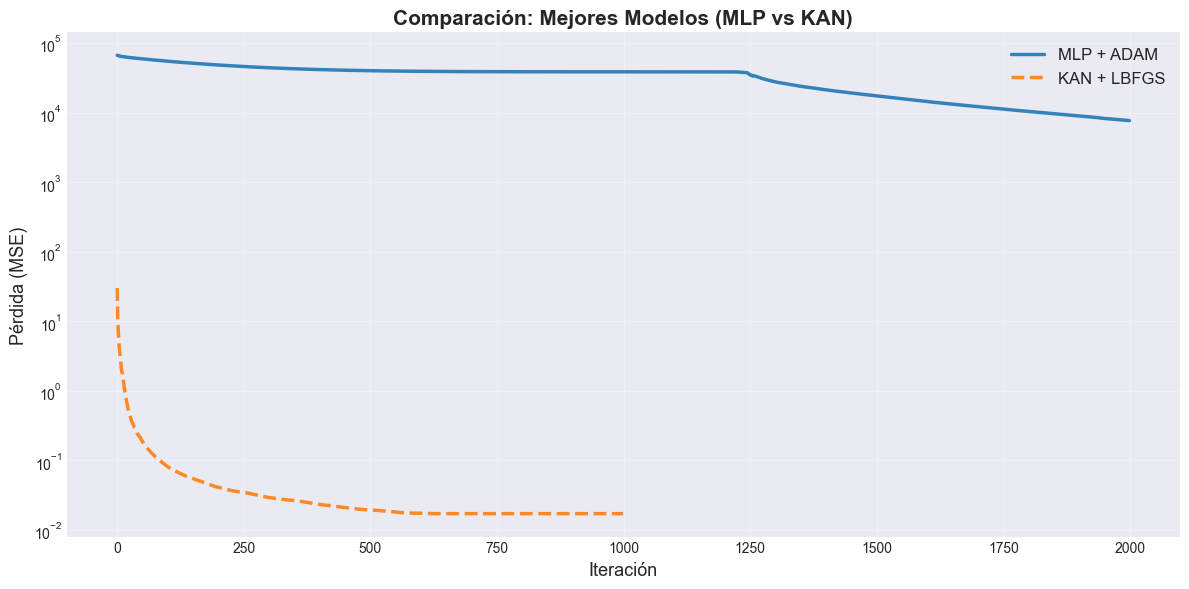


Métricas Finales - Mejores Modelos:
------------------------------------------------------------
Métrica              MLP                  KAN                 
------------------------------------------------------------
Test RMSE            8.644665e+01         6.600240e-01        
Test MAE             2.998680e+01         2.038276e-01        
Test L2              1.728933e+03         1.320048e+01        
Test L∞              4.907191e+02         7.960777e+00        
Final Loss           7.712368e+03         2.951735e-04        
Grad Norm            4.483355e+02         5.893421e-03        
Iteraciones          2000                 1000                
Parámetros           8577                 3506                
Tiempo (s)           1.535116e+01         1.286729e+03        
------------------------------------------------------------


In [10]:
# Comparar mejores modelos
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

if 'mlp' in best_optimizers:
    best_mlp_opt = best_optimizers['mlp']['optimizer']
    mlp_history = loss_histories['mlp'][best_mlp_opt]
    if len(mlp_history) > 0:
        ax.plot(mlp_history, label=f"MLP + {best_mlp_opt.upper()}", 
                linewidth=2.5, alpha=0.9, linestyle='-')

if 'kan' in best_optimizers:
    best_kan_opt = best_optimizers['kan']['optimizer']
    kan_history = loss_histories['kan'][best_kan_opt]
    if len(kan_history) > 0:
        ax.plot(kan_history, label=f"KAN + {best_kan_opt.upper()}", 
                linewidth=2.5, alpha=0.9, linestyle='--')

ax.set_xlabel('Iteración', fontsize=13)
ax.set_ylabel('Pérdida (MSE)', fontsize=13)
ax.set_title('Comparación: Mejores Modelos (MLP vs KAN)', fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar métricas finales
if 'mlp' in best_optimizers and 'kan' in best_optimizers:
    print("\nMétricas Finales - Mejores Modelos:")
    print("-" * 60)
    print(f"{'Métrica':<20} {'MLP':<20} {'KAN':<20}")
    print("-" * 60)
    
    mlp_res = best_optimizers['mlp']['result']
    kan_res = best_optimizers['kan']['result']
    
    metrics_to_show = [
        ('Test RMSE', 'test_metrics', 'rmse'),
        ('Test MAE', 'test_metrics', 'mae'),
        ('Test L2', 'test_metrics', 'l2'),
        ('Test L∞', 'test_metrics', 'linf'),
        ('Final Loss', None, 'final_loss'),
        ('Grad Norm', None, 'grad_norm'),
        ('Iteraciones', None, 'n_steps'),
        ('Parámetros', None, 'n_params'),
        ('Tiempo (s)', None, 'train_time_sec'),
    ]
    
    for metric_name, dict_key, key in metrics_to_show:
        if dict_key:
            mlp_val = mlp_res[dict_key][key]
            kan_val = kan_res[dict_key][key]
        else:
            mlp_val = mlp_res[key]
            kan_val = kan_res[key]
        
        if isinstance(mlp_val, float):
            print(f"{metric_name:<20} {mlp_val:<20.6e} {kan_val:<20.6e}")
        else:
            print(f"{metric_name:<20} {mlp_val:<20} {kan_val:<20}")
    
    print("-" * 60)


## Tabla Comparativa Detallada

Tabla completa con todas las métricas para todos los experimentos.


In [11]:
# Crear tabla comparativa
data_rows = []

for model_type in ["mlp", "kan"]:
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results[model_type]:
            res = results[model_type][opt_name]
            row = {
                'Modelo': model_type.upper(),
                'Optimizador': opt_name.upper(),
                'Test RMSE': res['test_metrics']['rmse'],
                'Test MAE': res['test_metrics']['mae'],
                'Test L2': res['test_metrics']['l2'],
                'Test L∞': res['test_metrics']['linf'],
                'Final Loss': res['final_loss'],
                'Grad Norm': res['grad_norm'],
                'Iteraciones': res['n_steps'],
                'Parámetros': res['n_params'],
                'Tiempo (s)': res.get('train_time_sec', 0),
            }
            data_rows.append(row)

df_comparison = pd.DataFrame(data_rows)

# Formatear números para mejor visualización
pd.set_option('display.float_format', lambda x: f'{x:.6e}' if abs(x) < 1e-3 or abs(x) > 1e3 else f'{x:.6f}')

print("\nTabla Comparativa Completa:")
print("="*120)
print(df_comparison.to_string(index=False))
print("="*120)

# Guardar tabla
df_comparison.to_csv('../outputs/rosenbrock_detailed_comparison.csv', index=False)
print("\n✓ Tabla guardada en: outputs/rosenbrock_detailed_comparison.csv")



Tabla Comparativa Completa:
Modelo Optimizador  Test RMSE   Test MAE      Test L2    Test L∞   Final Loss    Grad Norm  Iteraciones  Parámetros   Tiempo (s)
   MLP        ADAM  86.446649  29.986796 1.728933e+03 490.719105 7.712368e+03   448.335510         2000        8577    15.351156
   MLP       LBFGS 196.961753 153.613572 3.939235e+03 709.701344 3.889770e+04 1.573734e+03           62        8577     1.111891
   MLP  ADAM_LBFGS 196.735598 153.401794 3.934712e+03 709.103871 3.882674e+04     0.256811         1019        8577    10.129349
   KAN        ADAM   7.432656   4.928838   148.653110  53.874716    24.315554    27.557671         2000        3506   208.983284
   KAN       LBFGS   0.660024   0.203828    13.200480   7.960777 2.951735e-04     0.005893         1000        3506 1.286729e+03
   KAN  ADAM_LBFGS   0.805109   0.223774    16.102179   8.586327 4.713761e-04     0.004498         1500        3506   785.734205

✓ Tabla guardada en: outputs/rosenbrock_detailed_comparison.csv


## Visualización de Aproximaciones

Comparación visual de la función verdadera vs las aproximaciones de los mejores modelos.


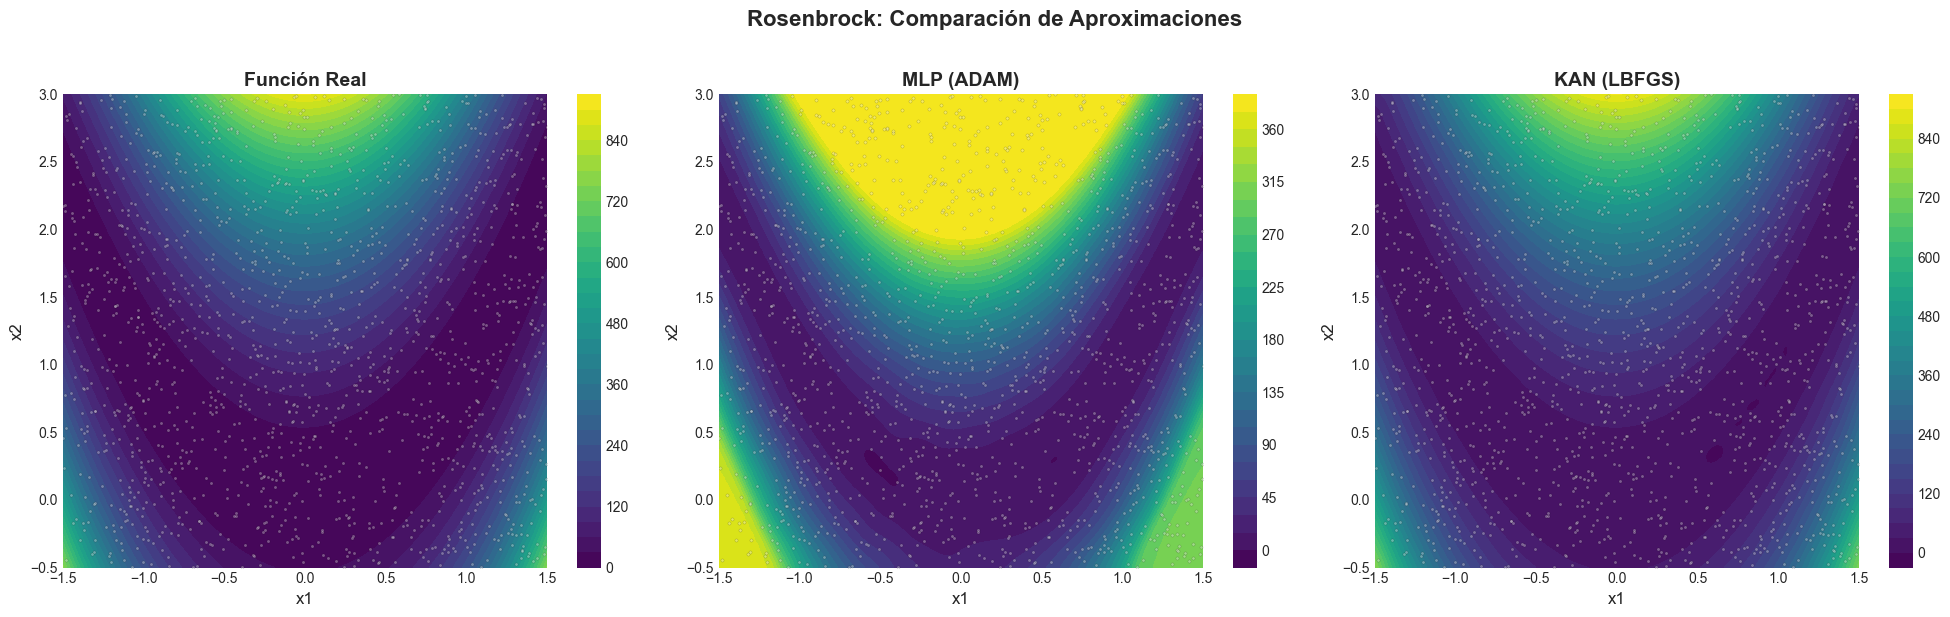


Errores en grilla completa:
  MLP - RMSE: 9.112179e+01, MAE: 3.158336e+01
  KAN - RMSE: 6.849333e-01, MAE: 2.026081e-01


In [12]:
# Obtener mejores modelos
if 'mlp' in best_optimizers and 'kan' in best_optimizers:
    mlp_model = best_optimizers['mlp']['result']['model']
    kan_model = best_optimizers['kan']['result']['model']
    
    # Predecir en la grilla
    y_mlp = mlp_model.predict(X_flat).reshape(X1g.shape)
    y_kan = kan_model.predict(X_flat).reshape(X1g.shape)
    
    # Crear figura con 3 paneles
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Función verdadera
    cs1 = axes[0].contourf(X1g, X2g, y_true_grid, levels=30, cmap='viridis')
    axes[0].scatter(X_train[:, 0], X_train[:, 1], s=5, alpha=0.3, c='white', 
                    edgecolors='k', linewidths=0.3)
    axes[0].set_title('Función Real', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x1', fontsize=12)
    axes[0].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs1, ax=axes[0])
    
    # MLP
    cs2 = axes[1].contourf(X1g, X2g, y_mlp, levels=30, cmap='viridis')
    axes[1].scatter(X_train[:, 0], X_train[:, 1], s=5, alpha=0.3, c='white', 
                    edgecolors='k', linewidths=0.3)
    best_mlp_opt = best_optimizers['mlp']['optimizer']
    axes[1].set_title(f"MLP ({best_mlp_opt.upper()})", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('x1', fontsize=12)
    axes[1].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs2, ax=axes[1])
    
    # KAN
    cs3 = axes[2].contourf(X1g, X2g, y_kan, levels=30, cmap='viridis')
    axes[2].scatter(X_train[:, 0], X_train[:, 1], s=5, alpha=0.3, c='white', 
                   edgecolors='k', linewidths=0.3)
    best_kan_opt = best_optimizers['kan']['optimizer']
    axes[2].set_title(f"KAN ({best_kan_opt.upper()})", fontsize=14, fontweight='bold')
    axes[2].set_xlabel('x1', fontsize=12)
    axes[2].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs3, ax=axes[2])
    
    plt.suptitle('Rosenbrock: Comparación de Aproximaciones', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Calcular errores en la grilla
    error_mlp = np.abs(y_mlp - y_true_grid)
    error_kan = np.abs(y_kan - y_true_grid)
    
    print(f"\nErrores en grilla completa:")
    print(f"  MLP - RMSE: {np.sqrt(np.mean(error_mlp**2)):.6e}, MAE: {np.mean(error_mlp):.6e}")
    print(f"  KAN - RMSE: {np.sqrt(np.mean(error_kan**2)):.6e}, MAE: {np.mean(error_kan):.6e}")
else:
    print("No hay suficientes resultados para comparar.")


C:\Users\sergiomarin\AppData\Local\Temp\ipykernel_27916\3430500501.py:20: UserWarning: The following kwargs were not used by contour: 'center'
  cs3 = axes[2].contourf(X1g, X2g, error_diff, levels=30, cmap='RdBu_r', center=0)


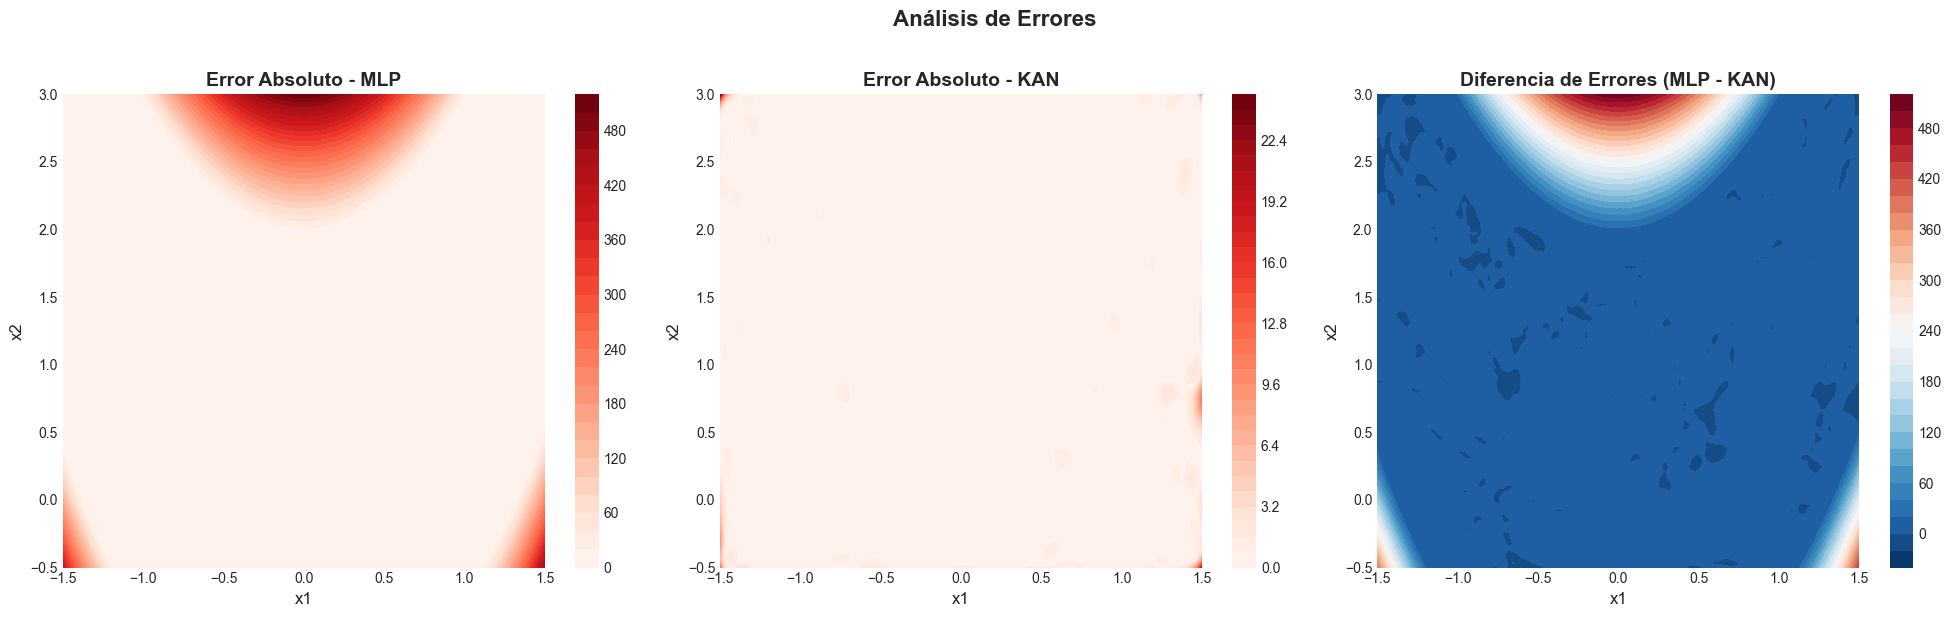

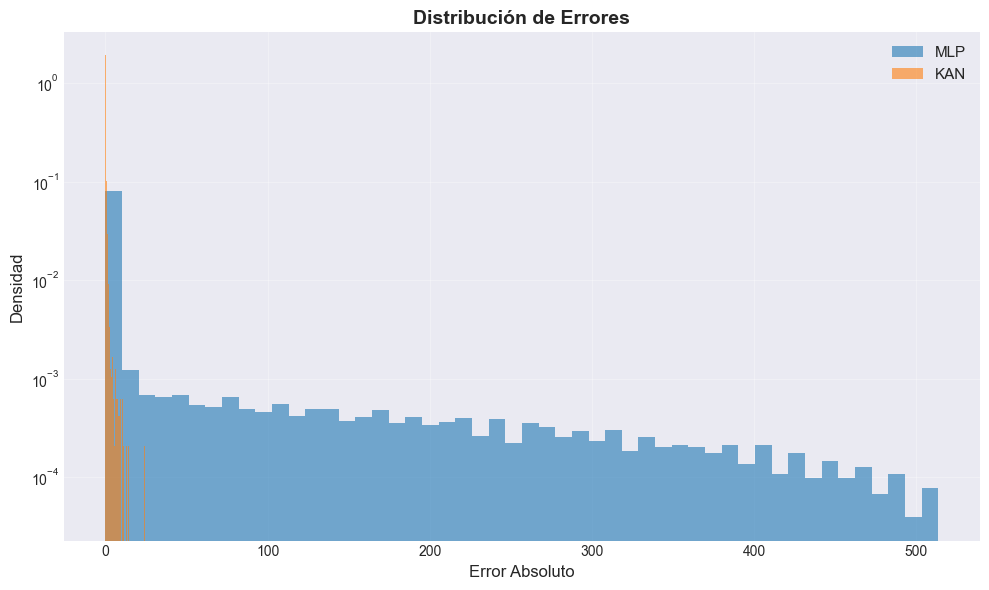

In [13]:
if 'mlp' in best_optimizers and 'kan' in best_optimizers:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Error MLP
    cs1 = axes[0].contourf(X1g, X2g, error_mlp, levels=30, cmap='Reds')
    axes[0].set_title('Error Absoluto - MLP', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('x1', fontsize=12)
    axes[0].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs1, ax=axes[0])
    
    # Error KAN
    cs2 = axes[1].contourf(X1g, X2g, error_kan, levels=30, cmap='Reds')
    axes[1].set_title('Error Absoluto - KAN', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('x1', fontsize=12)
    axes[1].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs2, ax=axes[1])
    
    # Diferencia de errores (MLP - KAN)
    error_diff = error_mlp - error_kan
    cs3 = axes[2].contourf(X1g, X2g, error_diff, levels=30, cmap='RdBu_r', center=0)
    axes[2].set_title('Diferencia de Errores (MLP - KAN)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('x1', fontsize=12)
    axes[2].set_ylabel('x2', fontsize=12)
    plt.colorbar(cs3, ax=axes[2])
    
    plt.suptitle('Análisis de Errores', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Histograma de errores
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.hist(error_mlp.ravel(), bins=50, alpha=0.6, label='MLP', density=True)
    ax.hist(error_kan.ravel(), bins=50, alpha=0.6, label='KAN', density=True)
    ax.set_xlabel('Error Absoluto', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.set_title('Distribución de Errores', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Análisis de Convergencia

Analizamos las características de convergencia de cada modelo-optimizador.


In [14]:
# Análisis de convergencia
convergence_analysis = []

for model_type in ["mlp", "kan"]:
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results[model_type]:
            res = results[model_type][opt_name]
            history = res['history']
            
            if len(history) > 0:
                initial_loss = history[0]
                final_loss = history[-1]
                reduction_factor = initial_loss / final_loss if final_loss > 0 else float('inf')
                
                # Encontrar iteración donde se alcanza 90% de reducción
                target_loss = initial_loss * 0.1
                iters_to_90 = None
                for i, loss in enumerate(history):
                    if loss <= target_loss:
                        iters_to_90 = i
                        break
                
                # Tasa de mejora promedio (log scale)
                if len(history) > 1:
                    log_losses = np.log(np.array(history) + 1e-10)
                    improvement_rate = -np.mean(np.diff(log_losses))
                else:
                    improvement_rate = 0
                
                convergence_analysis.append({
                    'Modelo': model_type.upper(),
                    'Optimizador': opt_name.upper(),
                    'Pérdida Inicial': initial_loss,
                    'Pérdida Final': final_loss,
                    'Factor Reducción': reduction_factor,
                    'Iteraciones a 90%': iters_to_90 if iters_to_90 else len(history),
                    'Tasa Mejora (log)': improvement_rate,
                    'Gradiente Final': res['grad_norm'],
                })

df_convergence = pd.DataFrame(convergence_analysis)
pd.set_option('display.float_format', lambda x: f'{x:.6e}' if abs(x) < 1e-3 or abs(x) > 1e3 else f'{x:.6f}')

print("\nAnálisis de Convergencia:")
print("="*100)
print(df_convergence.to_string(index=False))
print("="*100)



Análisis de Convergencia:
Modelo Optimizador Pérdida Inicial Pérdida Final  Factor Reducción  Iteraciones a 90%  Tasa Mejora (log)  Gradiente Final
   MLP        ADAM    6.724708e+04  7.723416e+03          8.706909               2000           0.001083       448.335510
   MLP       LBFGS    6.724708e+04  3.889770e+04          1.728819                 62           0.008974     1.573734e+03
   MLP  ADAM_LBFGS    6.724708e+04  3.882674e+04          1.731979               1019       5.395525e-04         0.256811
   KAN        ADAM       259.50552      4.937034         52.563042                 20           0.001982        27.557671
   KAN       LBFGS       30.142462    0.01718065      1.754443e+03                  6           0.007477         0.005893
   KAN  ADAM_LBFGS       30.147018   0.021711241      1.388544e+03                  7           0.004827         0.004498


## Resumen Final

Resumen de los hallazgos principales del análisis.


In [15]:
print("\n" + "="*80)
print("RESUMEN DEL ANÁLISIS - FUNCIÓN ROSENBROCK")
print("="*80)

if 'mlp' in best_optimizers:
    mlp_best = best_optimizers['mlp']
    print(f"\n✓ Mejor MLP:")
    print(f"  Optimizador: {mlp_best['optimizer'].upper()}")
    print(f"  Test RMSE: {mlp_best['rmse']:.6e}")
    print(f"  Iteraciones: {mlp_best['result']['n_steps']}")
    print(f"  Parámetros: {mlp_best['result']['n_params']}")
    print(f"  Tiempo: {mlp_best['result'].get('train_time_sec', 0):.2f}s")

if 'kan' in best_optimizers:
    kan_best = best_optimizers['kan']
    print(f"\n✓ Mejor KAN:")
    print(f"  Optimizador: {kan_best['optimizer'].upper()}")
    print(f"  Test RMSE: {kan_best['rmse']:.6e}")
    print(f"  Iteraciones: {kan_best['result']['n_steps']}")
    print(f"  Parámetros: {kan_best['result']['n_params']}")
    print(f"  Tiempo: {kan_best['result'].get('train_time_sec', 0):.2f}s")

if 'mlp' in best_optimizers and 'kan' in best_optimizers:
    mlp_rmse = best_optimizers['mlp']['rmse']
    kan_rmse = best_optimizers['kan']['rmse']
    
    print(f"\n✓ Comparación:")
    if mlp_rmse < kan_rmse:
        ratio = kan_rmse / mlp_rmse
        print(f"  MLP es {ratio:.2f}x mejor que KAN (RMSE más bajo)")
    else:
        ratio = mlp_rmse / kan_rmse
        print(f"  KAN es {ratio:.2f}x mejor que MLP (RMSE más bajo)")
    
    print(f"\n✓ Observaciones:")
    print(f"  - La función Rosenbrock tiene un valle largo y estrecho")
    print(f"  - Los optimizadores de segundo orden (LBFGS) suelen funcionar mejor")
    print(f"  - KAN puede capturar mejor la estructura no-lineal en algunas regiones")
    print(f"  - MLP puede requerir más parámetros pero converge más rápido")

print("\n" + "="*80)
print("ANÁLISIS COMPLETADO")
print("="*80)



RESUMEN DEL ANÁLISIS - FUNCIÓN ROSENBROCK

✓ Mejor MLP:
  Optimizador: ADAM
  Test RMSE: 8.644665e+01
  Iteraciones: 2000
  Parámetros: 8577
  Tiempo: 15.35s

✓ Mejor KAN:
  Optimizador: LBFGS
  Test RMSE: 6.600240e-01
  Iteraciones: 1000
  Parámetros: 3506
  Tiempo: 1286.73s

✓ Comparación:
  KAN es 130.98x mejor que MLP (RMSE más bajo)

✓ Observaciones:
  - La función Rosenbrock tiene un valle largo y estrecho
  - Los optimizadores de segundo orden (LBFGS) suelen funcionar mejor
  - KAN puede capturar mejor la estructura no-lineal en algunas regiones
  - MLP puede requerir más parámetros pero converge más rápido

ANÁLISIS COMPLETADO


## Análisis Detallado por Modelo: MLP

Análisis independiente de MLP con todos sus optimizadores, incluyendo métricas de rendimiento, convergencia y visualizaciones específicas.


In [16]:
# Análisis MLP - Tabla comparativa de optimizadores
if 'mlp' in results:
    mlp_data = []
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results['mlp']:
            res = results['mlp'][opt_name]
            mlp_data.append({
                'Optimizador': opt_name.upper(),
                'Test RMSE': res['test_metrics']['rmse'],
                'Test MAE': res['test_metrics']['mae'],
                'Test L∞': res['test_metrics']['linf'],
                'Final Loss': res['final_loss'],
                'Grad Norm': res['grad_norm'],
                'Iteraciones': res['n_steps'],
                'Parámetros': res['n_params'],
                'Tiempo (s)': res.get('train_time_sec', 0),
                'FLOPs (aprox)': res['approx_flops'],
            })
    
    df_mlp = pd.DataFrame(mlp_data)
    pd.set_option('display.float_format', lambda x: f'{x:.6e}' if abs(x) < 1e-3 or abs(x) > 1e3 else f'{x:.6f}')
    
    print("="*100)
    print("ANÁLISIS COMPARATIVO - MLP")
    print("="*100)
    print(df_mlp.to_string(index=False))
    print("="*100)
    
    # Identificar mejor y peor optimizador para MLP
    best_mlp_idx = df_mlp['Test RMSE'].idxmin()
    worst_mlp_idx = df_mlp['Test RMSE'].idxmax()
    
    print(f"\n✓ Mejor optimizador MLP: {df_mlp.loc[best_mlp_idx, 'Optimizador']}")
    print(f"  Test RMSE: {df_mlp.loc[best_mlp_idx, 'Test RMSE']:.6e}")
    print(f"  Tiempo: {df_mlp.loc[best_mlp_idx, 'Tiempo (s)']:.2f}s")
    
    print(f"\n✗ Peor optimizador MLP: {df_mlp.loc[worst_mlp_idx, 'Optimizador']}")
    print(f"  Test RMSE: {df_mlp.loc[worst_mlp_idx, 'Test RMSE']:.6e}")
    print(f"  Tiempo: {df_mlp.loc[worst_mlp_idx, 'Tiempo (s)']:.2f}s")
    
    ratio_mlp = df_mlp.loc[worst_mlp_idx, 'Test RMSE'] / df_mlp.loc[best_mlp_idx, 'Test RMSE']
    print(f"\n  Diferencia: {ratio_mlp:.2f}x entre mejor y peor")
else:
    print("No hay resultados de MLP disponibles.")


ANÁLISIS COMPARATIVO - MLP
Optimizador  Test RMSE   Test MAE    Test L∞   Final Loss    Grad Norm  Iteraciones  Parámetros  Tiempo (s)  FLOPs (aprox)
       ADAM  86.446649  29.986796 490.719105 7.712368e+03   448.335510         2000        8577   15.351156   5.489280e+10
      LBFGS 196.961753 153.613572 709.701344 3.889770e+04 1.573734e+03           62        8577    1.111891   1.701677e+09
 ADAM_LBFGS 196.735598 153.401794 709.103871 3.882674e+04     0.256811         1019        8577   10.129349   2.796788e+10

✓ Mejor optimizador MLP: ADAM
  Test RMSE: 8.644665e+01
  Tiempo: 15.35s

✗ Peor optimizador MLP: LBFGS
  Test RMSE: 1.969618e+02
  Tiempo: 1.11s

  Diferencia: 2.28x entre mejor y peor


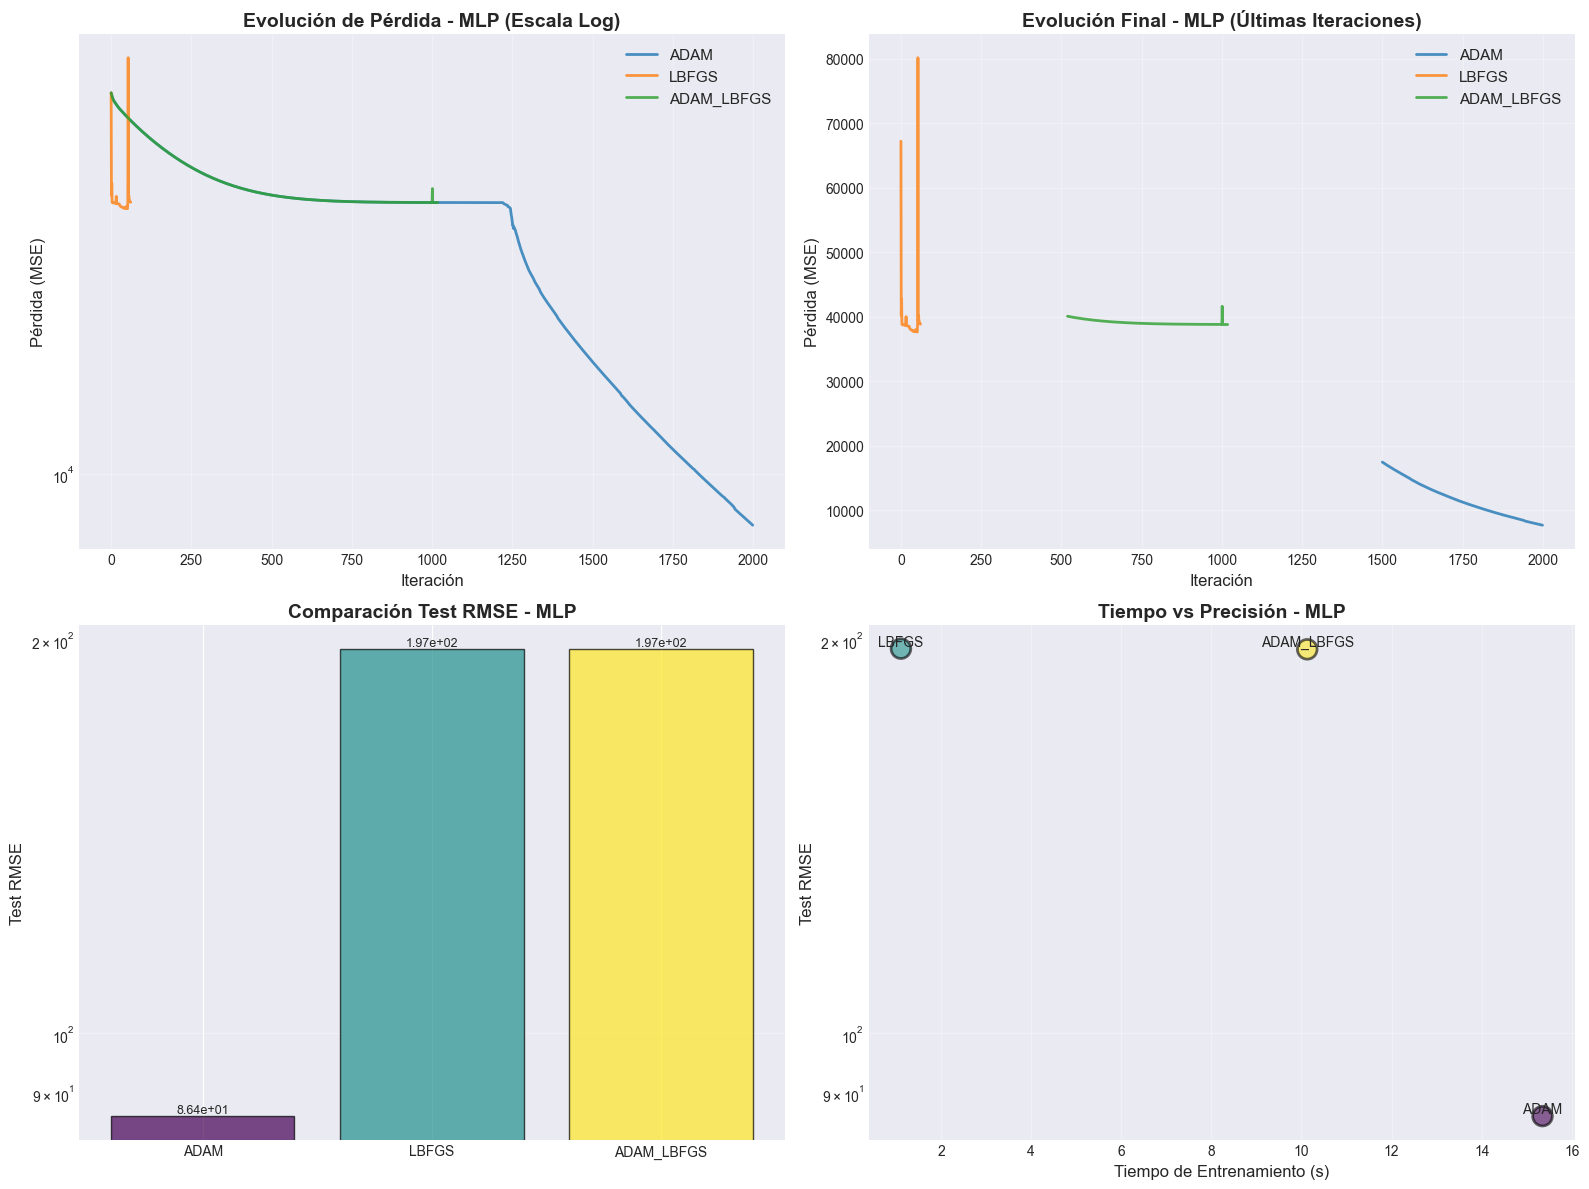

In [17]:
# Visualización comparativa de curvas de pérdida - MLP
if 'mlp' in loss_histories:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Curvas de pérdida (escala log)
    ax1 = axes[0, 0]
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in loss_histories['mlp']:
            history = loss_histories['mlp'][opt_name]
            if len(history) > 0:
                ax1.plot(history, label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
    ax1.set_xlabel('Iteración', fontsize=12)
    ax1.set_ylabel('Pérdida (MSE)', fontsize=12)
    ax1.set_title('Evolución de Pérdida - MLP (Escala Log)', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. Curvas de pérdida (escala lineal - últimas iteraciones)
    ax2 = axes[0, 1]
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in loss_histories['mlp']:
            history = loss_histories['mlp'][opt_name]
            if len(history) > 100:
                # Mostrar últimas 500 iteraciones
                history_tail = history[-500:]
                ax2.plot(range(len(history)-500, len(history)), history_tail, 
                        label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
            elif len(history) > 0:
                ax2.plot(history, label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
    ax2.set_xlabel('Iteración', fontsize=12)
    ax2.set_ylabel('Pérdida (MSE)', fontsize=12)
    ax2.set_title('Evolución Final - MLP (Últimas Iteraciones)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Comparación de métricas (bar chart)
    ax3 = axes[1, 0]
    if 'mlp' in results:
        opt_names = []
        rmse_values = []
        for opt_name in OPTIMIZERS_TO_TEST:
            if opt_name in results['mlp']:
                opt_names.append(opt_name.upper())
                rmse_values.append(results['mlp'][opt_name]['test_metrics']['rmse'])
        
        if opt_names:
            colors = plt.cm.viridis(np.linspace(0, 1, len(opt_names)))
            bars = ax3.bar(opt_names, rmse_values, color=colors, alpha=0.7, edgecolor='black')
            ax3.set_ylabel('Test RMSE', fontsize=12)
            ax3.set_title('Comparación Test RMSE - MLP', fontsize=14, fontweight='bold')
            ax3.set_yscale('log')
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Agregar valores en las barras
            for bar, val in zip(bars, rmse_values):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2e}', ha='center', va='bottom', fontsize=9)
    
    # 4. Tiempo vs RMSE (scatter plot)
    ax4 = axes[1, 1]
    if 'mlp' in results:
        times = []
        rmses = []
        labels = []
        for opt_name in OPTIMIZERS_TO_TEST:
            if opt_name in results['mlp']:
                res = results['mlp'][opt_name]
                times.append(res.get('train_time_sec', 0))
                rmses.append(res['test_metrics']['rmse'])
                labels.append(opt_name.upper())
        
        if times:
            scatter = ax4.scatter(times, rmses, s=200, alpha=0.6, c=range(len(times)), 
                                 cmap='viridis', edgecolors='black', linewidths=2)
            for i, label in enumerate(labels):
                ax4.annotate(label, (times[i], rmses[i]), fontsize=10, 
                           ha='center', va='bottom')
            ax4.set_xlabel('Tiempo de Entrenamiento (s)', fontsize=12)
            ax4.set_ylabel('Test RMSE', fontsize=12)
            ax4.set_title('Tiempo vs Precisión - MLP', fontsize=14, fontweight='bold')
            ax4.set_yscale('log')
            ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [18]:
# Análisis de convergencia detallado - MLP
if 'mlp' in results:
    print("\n" + "="*100)
    print("ANÁLISIS DE CONVERGENCIA - MLP")
    print("="*100)
    
    convergence_mlp = []
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results['mlp']:
            res = results['mlp'][opt_name]
            history = res['history']
            
            if len(history) > 0:
                initial_loss = history[0]
                final_loss = history[-1]
                
                # Calcular tasa de convergencia promedio
                if len(history) > 1:
                    reductions = []
                    for i in range(1, len(history)):
                        if history[i-1] > 0:
                            reduction = (history[i-1] - history[i]) / history[i-1]
                            reductions.append(reduction)
                    avg_reduction_rate = np.mean(reductions) if reductions else 0
                else:
                    avg_reduction_rate = 0
                
                # Iteraciones para alcanzar diferentes umbrales
                thresholds = [0.9, 0.5, 0.1]  # 90%, 50%, 10% de pérdida inicial
                iters_to_threshold = {}
                for thresh in thresholds:
                    target = initial_loss * (1 - thresh)
                    iters_to_threshold[f'{int(thresh*100)}%'] = None
                    for i, loss in enumerate(history):
                        if loss <= target:
                            iters_to_threshold[f'{int(thresh*100)}%'] = i
                            break
                
                convergence_mlp.append({
                    'Optimizador': opt_name.upper(),
                    'Pérdida Inicial': initial_loss,
                    'Pérdida Final': final_loss,
                    'Reducción Total': (initial_loss - final_loss) / initial_loss * 100,
                    'Tasa Reducción Promedio': avg_reduction_rate * 100,
                    'Iteraciones a 90%': iters_to_threshold.get('90%', len(history)),
                    'Iteraciones a 50%': iters_to_threshold.get('50%', len(history)),
                    'Iteraciones a 10%': iters_to_threshold.get('10%', len(history)),
                })
    
    if convergence_mlp:
        df_conv_mlp = pd.DataFrame(convergence_mlp)
        pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.0f}')
        print(df_conv_mlp.to_string(index=False))
        print("="*100)



ANÁLISIS DE CONVERGENCIA - MLP
Optimizador  Pérdida Inicial  Pérdida Final  Reducción Total  Tasa Reducción Promedio Iteraciones a 90%  Iteraciones a 50%  Iteraciones a 10%
       ADAM            67247           7723          88.5149                   0.1081              None               1261                 41
      LBFGS            67247          38898          42.1570                  -0.1746              None                NaN                  1
 ADAM_LBFGS            67247          38827          42.2626                   0.0534              None                NaN                 41


## Análisis Detallado por Modelo: KAN

Análisis independiente de KAN con todos sus optimizadores, incluyendo métricas de rendimiento, convergencia y visualizaciones específicas.


In [19]:
# Análisis KAN - Tabla comparativa de optimizadores
if 'kan' in results:
    kan_data = []
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results['kan']:
            res = results['kan'][opt_name]
            kan_data.append({
                'Optimizador': opt_name.upper(),
                'Test RMSE': res['test_metrics']['rmse'],
                'Test MAE': res['test_metrics']['mae'],
                'Test L∞': res['test_metrics']['linf'],
                'Final Loss': res['final_loss'],
                'Grad Norm': res['grad_norm'],
                'Iteraciones': res['n_steps'],
                'Parámetros': res['n_params'],
                'Tiempo (s)': res.get('train_time_sec', 0),
                'FLOPs (aprox)': res['approx_flops'],
            })
    
    df_kan = pd.DataFrame(kan_data)
    pd.set_option('display.float_format', lambda x: f'{x:.6e}' if abs(x) < 1e-3 or abs(x) > 1e3 else f'{x:.6f}')
    
    print("="*100)
    print("ANÁLISIS COMPARATIVO - KAN")
    print("="*100)
    print(df_kan.to_string(index=False))
    print("="*100)
    
    # Identificar mejor y peor optimizador para KAN
    best_kan_idx = df_kan['Test RMSE'].idxmin()
    worst_kan_idx = df_kan['Test RMSE'].idxmax()
    
    print(f"\n✓ Mejor optimizador KAN: {df_kan.loc[best_kan_idx, 'Optimizador']}")
    print(f"  Test RMSE: {df_kan.loc[best_kan_idx, 'Test RMSE']:.6e}")
    print(f"  Tiempo: {df_kan.loc[best_kan_idx, 'Tiempo (s)']:.2f}s")
    
    print(f"\n✗ Peor optimizador KAN: {df_kan.loc[worst_kan_idx, 'Optimizador']}")
    print(f"  Test RMSE: {df_kan.loc[worst_kan_idx, 'Test RMSE']:.6e}")
    print(f"  Tiempo: {df_kan.loc[worst_kan_idx, 'Tiempo (s)']:.2f}s")
    
    ratio_kan = df_kan.loc[worst_kan_idx, 'Test RMSE'] / df_kan.loc[best_kan_idx, 'Test RMSE']
    print(f"\n  Diferencia: {ratio_kan:.2f}x entre mejor y peor")
else:
    print("No hay resultados de KAN disponibles.")


ANÁLISIS COMPARATIVO - KAN
Optimizador  Test RMSE  Test MAE   Test L∞   Final Loss  Grad Norm  Iteraciones  Parámetros   Tiempo (s)  FLOPs (aprox)
       ADAM   7.432656  4.928838 53.874716    24.315554  27.557671         2000        3506   208.983284   2.243840e+10
      LBFGS   0.660024  0.203828  7.960777 2.951735e-04   0.005893         1000        3506 1.286729e+03   1.121920e+10
 ADAM_LBFGS   0.805109  0.223774  8.586327 4.713761e-04   0.004498         1500        3506   785.734205   1.682880e+10

✓ Mejor optimizador KAN: LBFGS
  Test RMSE: 6.600240e-01
  Tiempo: 1286.73s

✗ Peor optimizador KAN: ADAM
  Test RMSE: 7.432656e+00
  Tiempo: 208.98s

  Diferencia: 11.26x entre mejor y peor


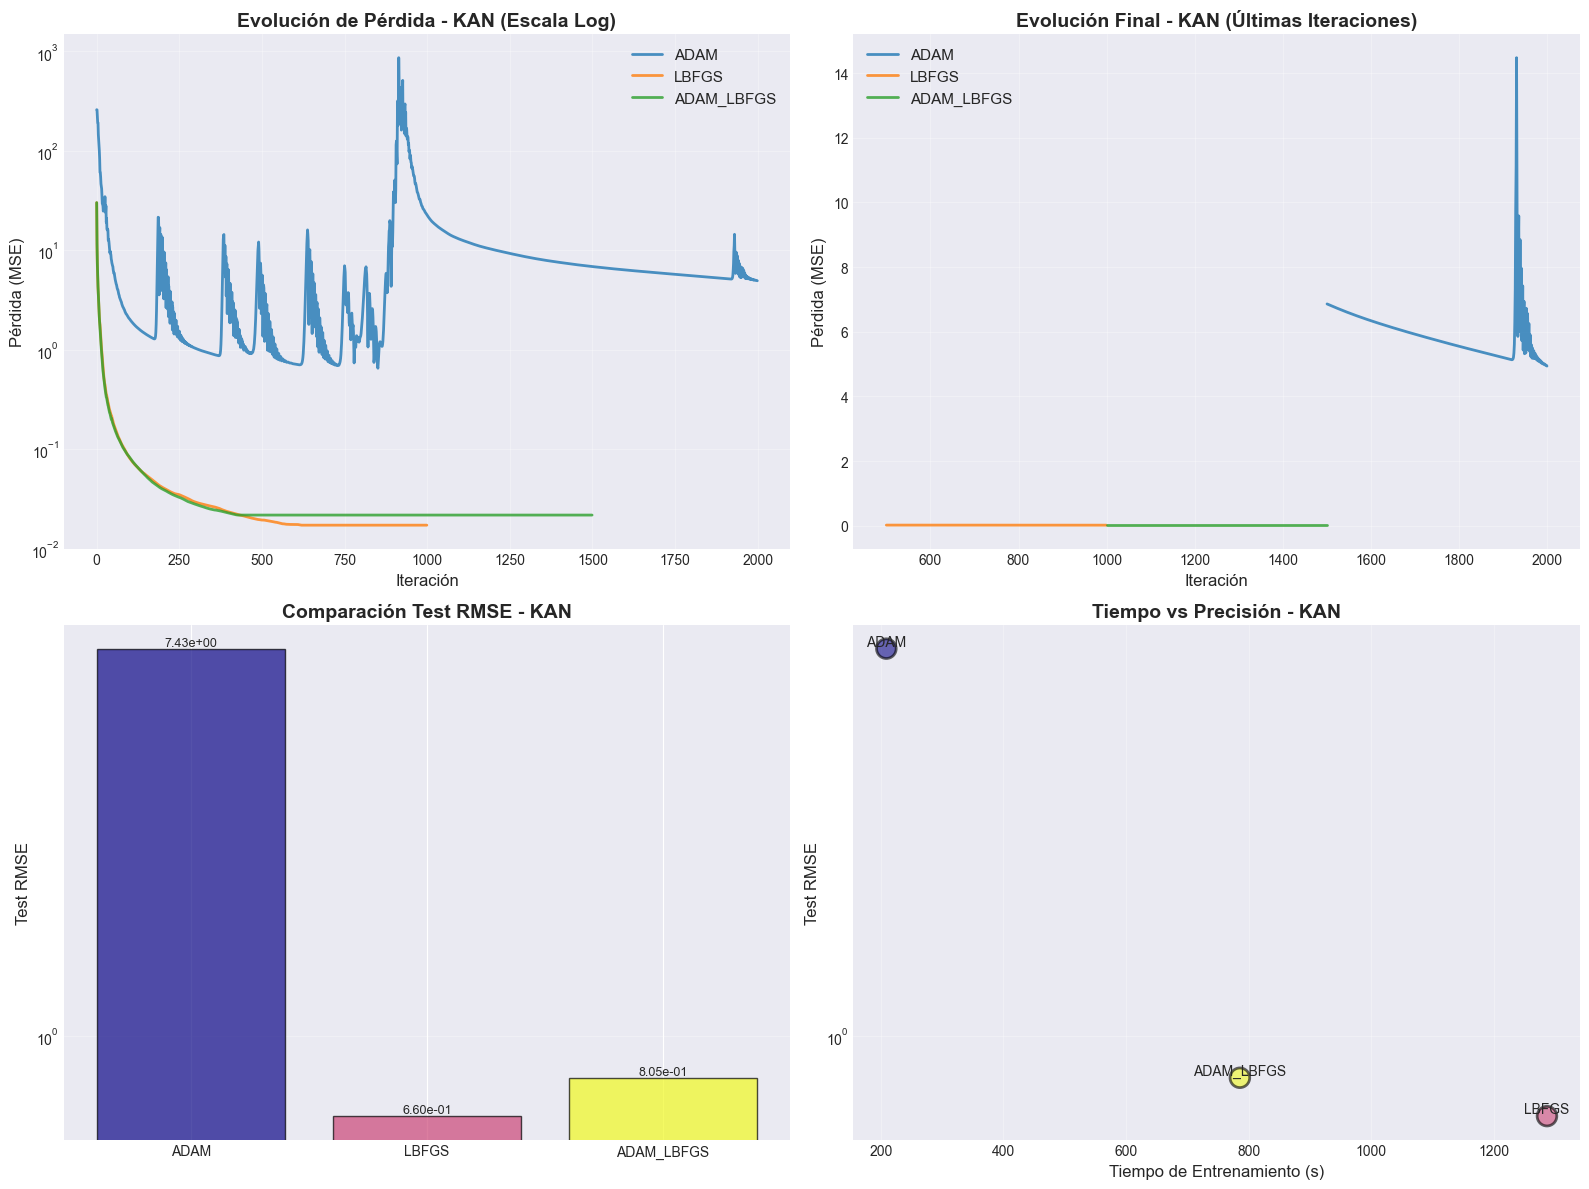

In [20]:
# Visualización comparativa de curvas de pérdida - KAN
if 'kan' in loss_histories:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Curvas de pérdida (escala log)
    ax1 = axes[0, 0]
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in loss_histories['kan']:
            history = loss_histories['kan'][opt_name]
            if len(history) > 0:
                ax1.plot(history, label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
    ax1.set_xlabel('Iteración', fontsize=12)
    ax1.set_ylabel('Pérdida (MSE)', fontsize=12)
    ax1.set_title('Evolución de Pérdida - KAN (Escala Log)', fontsize=14, fontweight='bold')
    ax1.set_yscale('log')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. Curvas de pérdida (escala lineal - últimas iteraciones)
    ax2 = axes[0, 1]
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in loss_histories['kan']:
            history = loss_histories['kan'][opt_name]
            if len(history) > 100:
                # Mostrar últimas 500 iteraciones
                history_tail = history[-500:]
                ax2.plot(range(len(history)-500, len(history)), history_tail, 
                        label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
            elif len(history) > 0:
                ax2.plot(history, label=f"{opt_name.upper()}", linewidth=2, alpha=0.8)
    ax2.set_xlabel('Iteración', fontsize=12)
    ax2.set_ylabel('Pérdida (MSE)', fontsize=12)
    ax2.set_title('Evolución Final - KAN (Últimas Iteraciones)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Comparación de métricas (bar chart)
    ax3 = axes[1, 0]
    if 'kan' in results:
        opt_names = []
        rmse_values = []
        for opt_name in OPTIMIZERS_TO_TEST:
            if opt_name in results['kan']:
                opt_names.append(opt_name.upper())
                rmse_values.append(results['kan'][opt_name]['test_metrics']['rmse'])
        
        if opt_names:
            colors = plt.cm.plasma(np.linspace(0, 1, len(opt_names)))
            bars = ax3.bar(opt_names, rmse_values, color=colors, alpha=0.7, edgecolor='black')
            ax3.set_ylabel('Test RMSE', fontsize=12)
            ax3.set_title('Comparación Test RMSE - KAN', fontsize=14, fontweight='bold')
            ax3.set_yscale('log')
            ax3.grid(True, alpha=0.3, axis='y')
            
            # Agregar valores en las barras
            for bar, val in zip(bars, rmse_values):
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2e}', ha='center', va='bottom', fontsize=9)
    
    # 4. Tiempo vs RMSE (scatter plot)
    ax4 = axes[1, 1]
    if 'kan' in results:
        times = []
        rmses = []
        labels = []
        for opt_name in OPTIMIZERS_TO_TEST:
            if opt_name in results['kan']:
                res = results['kan'][opt_name]
                times.append(res.get('train_time_sec', 0))
                rmses.append(res['test_metrics']['rmse'])
                labels.append(opt_name.upper())
        
        if times:
            scatter = ax4.scatter(times, rmses, s=200, alpha=0.6, c=range(len(times)), 
                                 cmap='plasma', edgecolors='black', linewidths=2)
            for i, label in enumerate(labels):
                ax4.annotate(label, (times[i], rmses[i]), fontsize=10, 
                           ha='center', va='bottom')
            ax4.set_xlabel('Tiempo de Entrenamiento (s)', fontsize=12)
            ax4.set_ylabel('Test RMSE', fontsize=12)
            ax4.set_title('Tiempo vs Precisión - KAN', fontsize=14, fontweight='bold')
            ax4.set_yscale('log')
            ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [21]:
# Análisis de convergencia detallado - KAN
if 'kan' in results:
    print("\n" + "="*100)
    print("ANÁLISIS DE CONVERGENCIA - KAN")
    print("="*100)
    
    convergence_kan = []
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results['kan']:
            res = results['kan'][opt_name]
            history = res['history']
            
            if len(history) > 0:
                initial_loss = history[0]
                final_loss = history[-1]
                
                # Calcular tasa de convergencia promedio
                if len(history) > 1:
                    reductions = []
                    for i in range(1, len(history)):
                        if history[i-1] > 0:
                            reduction = (history[i-1] - history[i]) / history[i-1]
                            reductions.append(reduction)
                    avg_reduction_rate = np.mean(reductions) if reductions else 0
                else:
                    avg_reduction_rate = 0
                
                # Iteraciones para alcanzar diferentes umbrales
                thresholds = [0.9, 0.5, 0.1]  # 90%, 50%, 10% de pérdida inicial
                iters_to_threshold = {}
                for thresh in thresholds:
                    target = initial_loss * (1 - thresh)
                    iters_to_threshold[f'{int(thresh*100)}%'] = None
                    for i, loss in enumerate(history):
                        if loss <= target:
                            iters_to_threshold[f'{int(thresh*100)}%'] = i
                            break
                
                convergence_kan.append({
                    'Optimizador': opt_name.upper(),
                    'Pérdida Inicial': initial_loss,
                    'Pérdida Final': final_loss,
                    'Reducción Total': (initial_loss - final_loss) / initial_loss * 100,
                    'Tasa Reducción Promedio': avg_reduction_rate * 100,
                    'Iteraciones a 90%': iters_to_threshold.get('90%', len(history)),
                    'Iteraciones a 50%': iters_to_threshold.get('50%', len(history)),
                    'Iteraciones a 10%': iters_to_threshold.get('10%', len(history)),
                })
    
    if convergence_kan:
        df_conv_kan = pd.DataFrame(convergence_kan)
        pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.0f}')
        print(df_conv_kan.to_string(index=False))
        print("="*100)



ANÁLISIS DE CONVERGENCIA - KAN
Optimizador Pérdida Inicial Pérdida Final  Reducción Total  Tasa Reducción Promedio  Iteraciones a 90%  Iteraciones a 50%  Iteraciones a 10%
       ADAM       259.50552      4.937034          98.0975                  -2.1085                 20                  6                  2
      LBFGS       30.142462    0.01718065          99.9430                   0.6801                  6                  1                  1
 ADAM_LBFGS       30.147018   0.021711241          99.9280                   0.4387                  7                  1                  1


## Análisis de Costo Computacional

Análisis detallado del costo computacional de cada modelo y optimizador, incluyendo tiempo de ejecución, complejidad computacional, eficiencia y relación costo-beneficio.


In [22]:
# Análisis de costo computacional completo
computational_data = []

for model_type in ["mlp", "kan"]:
    for opt_name in OPTIMIZERS_TO_TEST:
        if opt_name in results[model_type]:
            res = results[model_type][opt_name]
            time_sec = res.get('train_time_sec', 0)
            n_steps = res['n_steps']
            n_params = res['n_params']
            flops = res['approx_flops']
            rmse = res['test_metrics']['rmse']
            
            # Métricas derivadas
            time_per_iter = time_sec / n_steps if n_steps > 0 else 0
            flops_per_sec = flops / time_sec if time_sec > 0 else 0
            efficiency_score = rmse / time_sec if time_sec > 0 else float('inf')  # Menor es mejor
            
            computational_data.append({
                'Modelo': model_type.upper(),
                'Optimizador': opt_name.upper(),
                'Tiempo Total (s)': time_sec,
                'Iteraciones': n_steps,
                'Tiempo/Iteración (s)': time_per_iter,
                'Parámetros': n_params,
                'FLOPs Totales': flops,
                'FLOPs/segundo': flops_per_sec,
                'Test RMSE': rmse,
                'Eficiencia (RMSE/s)': efficiency_score,
            })

df_computational = pd.DataFrame(computational_data)

print("="*120)
print("ANÁLISIS DE COSTO COMPUTACIONAL")
print("="*120)
pd.set_option('display.float_format', lambda x: f'{x:.4e}' if abs(x) < 1e-3 or abs(x) > 1e6 else f'{x:.2f}')
print(df_computational.to_string(index=False))
print("="*120)


ANÁLISIS DE COSTO COMPUTACIONAL
Modelo Optimizador  Tiempo Total (s)  Iteraciones  Tiempo/Iteración (s)  Parámetros  FLOPs Totales  FLOPs/segundo  Test RMSE  Eficiencia (RMSE/s)
   MLP        ADAM             15.35         2000                  0.01        8577     5.4893e+10     3.5758e+09      86.45                 5.63
   MLP       LBFGS              1.11           62                  0.02        8577     1.7017e+09     1.5304e+09     196.96               177.14
   MLP  ADAM_LBFGS             10.13         1019                  0.01        8577     2.7968e+10     2.7611e+09     196.74                19.42
   KAN        ADAM            208.98         2000                  0.10        3506     2.2438e+10     1.0737e+08       7.43                 0.04
   KAN       LBFGS           1286.73         1000                  1.29        3506     1.1219e+10     8.7192e+06       0.66           5.1295e-04
   KAN  ADAM_LBFGS            785.73         1500                  0.52        3506     1.68

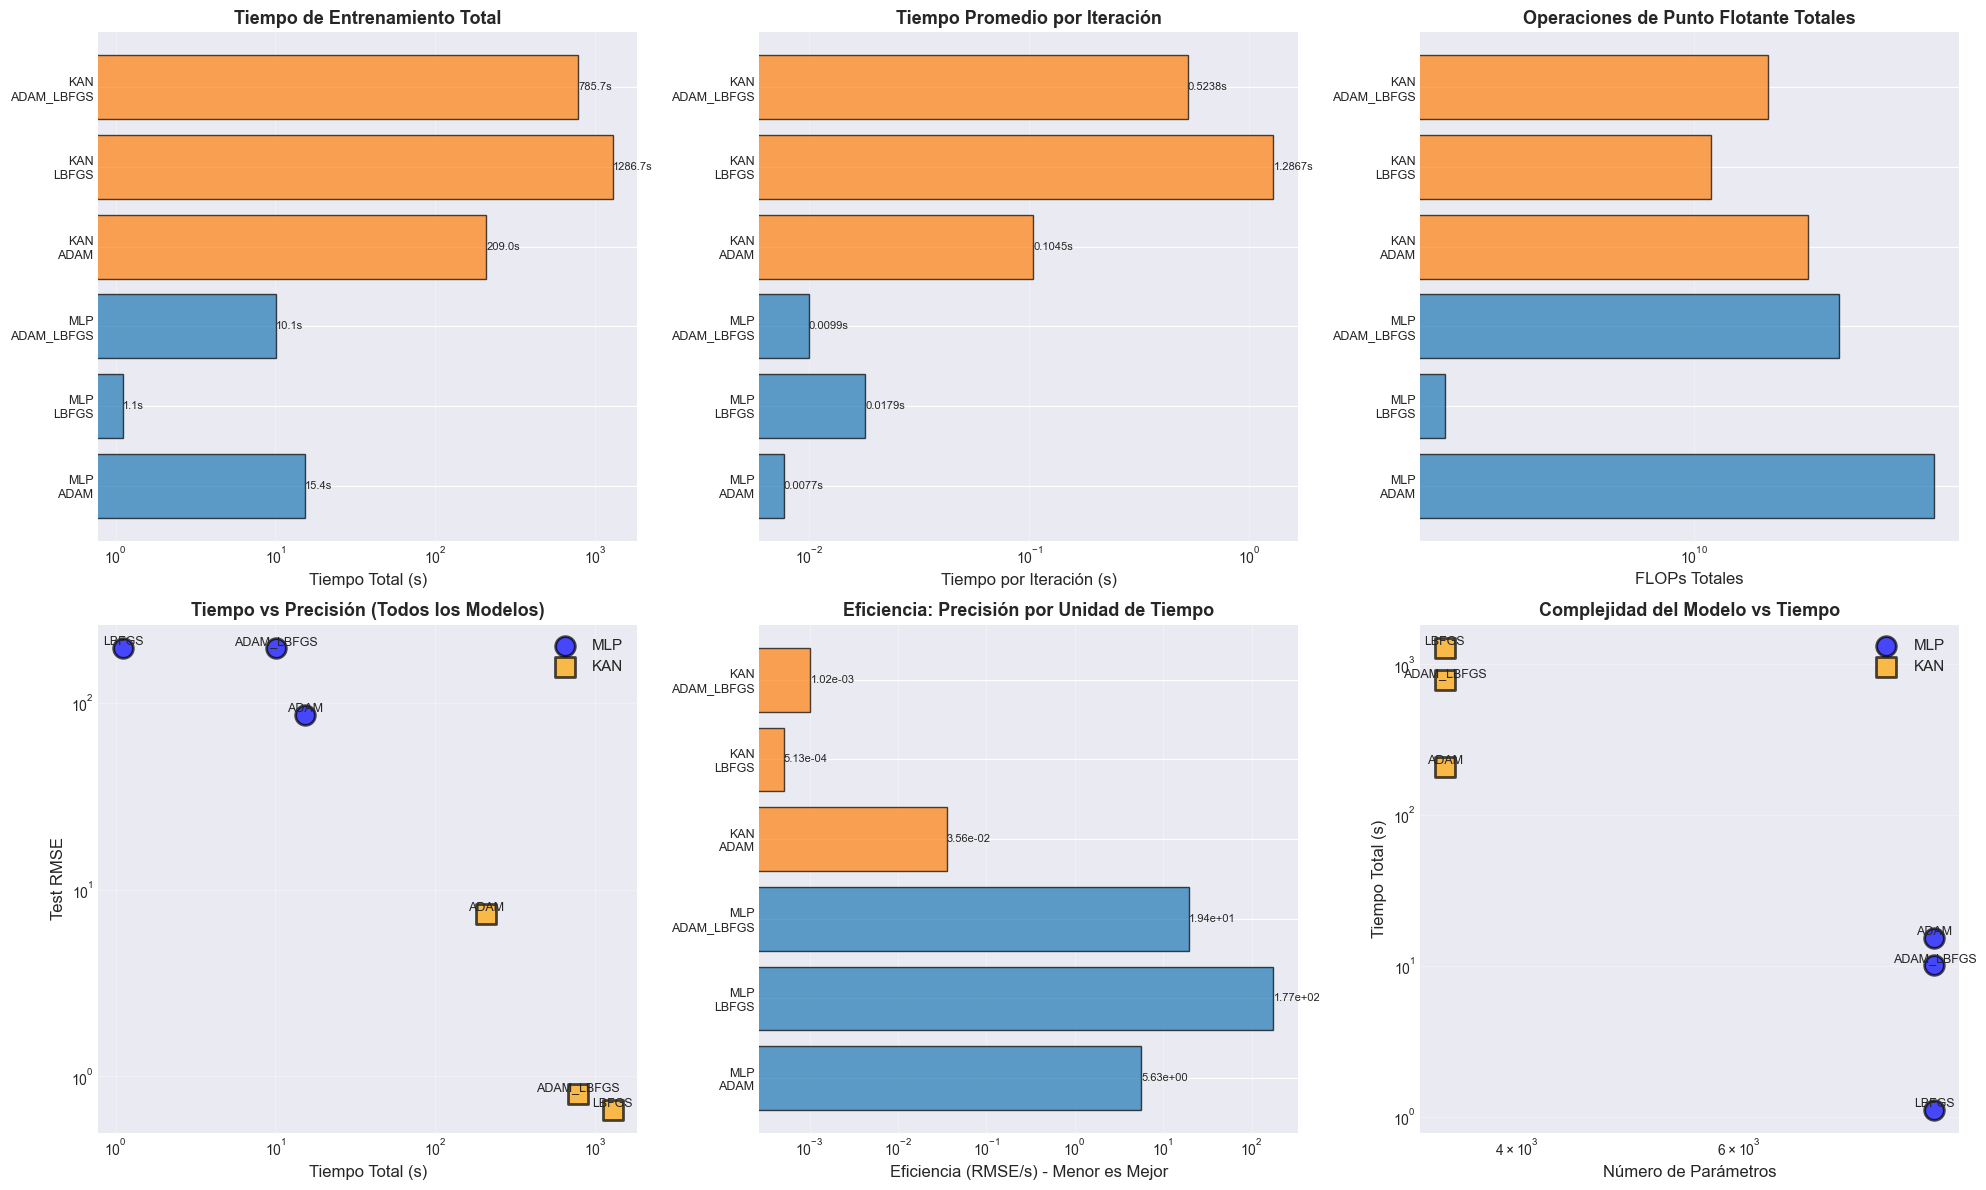

In [23]:
# Visualizaciones de costo computacional
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Tiempo total por modelo-optimizador
ax1 = axes[0, 0]
if len(computational_data) > 0:
    labels = [f"{row['Modelo']}\n{row['Optimizador']}" for row in computational_data]
    times = [row['Tiempo Total (s)'] for row in computational_data]
    colors = ['#1f77b4' if 'MLP' in label else '#ff7f0e' for label in labels]
    bars1 = ax1.barh(range(len(labels)), times, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_yticks(range(len(labels)))
    ax1.set_yticklabels(labels, fontsize=9)
    ax1.set_xlabel('Tiempo Total (s)', fontsize=12)
    ax1.set_title('Tiempo de Entrenamiento Total', fontsize=13, fontweight='bold')
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars1, times)):
        ax1.text(val, i, f'{val:.1f}s', va='center', ha='left', fontsize=8)

# 2. Tiempo por iteración
ax2 = axes[0, 1]
if len(computational_data) > 0:
    labels = [f"{row['Modelo']}\n{row['Optimizador']}" for row in computational_data]
    time_per_iter = [row['Tiempo/Iteración (s)'] for row in computational_data]
    colors = ['#1f77b4' if 'MLP' in label else '#ff7f0e' for label in labels]
    bars2 = ax2.barh(range(len(labels)), time_per_iter, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_yticks(range(len(labels)))
    ax2.set_yticklabels(labels, fontsize=9)
    ax2.set_xlabel('Tiempo por Iteración (s)', fontsize=12)
    ax2.set_title('Tiempo Promedio por Iteración', fontsize=13, fontweight='bold')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars2, time_per_iter)):
        ax2.text(val, i, f'{val:.4f}s', va='center', ha='left', fontsize=8)

# 3. FLOPs totales
ax3 = axes[0, 2]
if len(computational_data) > 0:
    labels = [f"{row['Modelo']}\n{row['Optimizador']}" for row in computational_data]
    flops = [row['FLOPs Totales'] for row in computational_data]
    colors = ['#1f77b4' if 'MLP' in label else '#ff7f0e' for label in labels]
    bars3 = ax3.barh(range(len(labels)), flops, color=colors, alpha=0.7, edgecolor='black')
    ax3.set_yticks(range(len(labels)))
    ax3.set_yticklabels(labels, fontsize=9)
    ax3.set_xlabel('FLOPs Totales', fontsize=12)
    ax3.set_title('Operaciones de Punto Flotante Totales', fontsize=13, fontweight='bold')
    ax3.set_xscale('log')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Tiempo vs Precisión (scatter)
ax4 = axes[1, 0]
if len(computational_data) > 0:
    mlp_times = [row['Tiempo Total (s)'] for row in computational_data if row['Modelo'] == 'MLP']
    mlp_rmses = [row['Test RMSE'] for row in computational_data if row['Modelo'] == 'MLP']
    mlp_opts = [row['Optimizador'] for row in computational_data if row['Modelo'] == 'MLP']
    
    kan_times = [row['Tiempo Total (s)'] for row in computational_data if row['Modelo'] == 'KAN']
    kan_rmses = [row['Test RMSE'] for row in computational_data if row['Modelo'] == 'KAN']
    kan_opts = [row['Optimizador'] for row in computational_data if row['Modelo'] == 'KAN']
    
    if mlp_times:
        ax4.scatter(mlp_times, mlp_rmses, s=200, alpha=0.7, c='blue', 
                   marker='o', edgecolors='black', linewidths=2, label='MLP')
        for i, opt in enumerate(mlp_opts):
            ax4.annotate(opt, (mlp_times[i], mlp_rmses[i]), fontsize=9, 
                        ha='center', va='bottom')
    
    if kan_times:
        ax4.scatter(kan_times, kan_rmses, s=200, alpha=0.7, c='orange', 
                   marker='s', edgecolors='black', linewidths=2, label='KAN')
        for i, opt in enumerate(kan_opts):
            ax4.annotate(opt, (kan_times[i], kan_rmses[i]), fontsize=9, 
                        ha='center', va='bottom')
    
    ax4.set_xlabel('Tiempo Total (s)', fontsize=12)
    ax4.set_ylabel('Test RMSE', fontsize=12)
    ax4.set_title('Tiempo vs Precisión (Todos los Modelos)', fontsize=13, fontweight='bold')
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)

# 5. Eficiencia (RMSE/Tiempo) - menor es mejor
ax5 = axes[1, 1]
if len(computational_data) > 0:
    labels = [f"{row['Modelo']}\n{row['Optimizador']}" for row in computational_data]
    efficiency = [row['Eficiencia (RMSE/s)'] for row in computational_data]
    colors = ['#1f77b4' if 'MLP' in label else '#ff7f0e' for label in labels]
    bars5 = ax5.barh(range(len(labels)), efficiency, color=colors, alpha=0.7, edgecolor='black')
    ax5.set_yticks(range(len(labels)))
    ax5.set_yticklabels(labels, fontsize=9)
    ax5.set_xlabel('Eficiencia (RMSE/s) - Menor es Mejor', fontsize=12)
    ax5.set_title('Eficiencia: Precisión por Unidad de Tiempo', fontsize=13, fontweight='bold')
    ax5.set_xscale('log')
    ax5.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars5, efficiency)):
        if np.isfinite(val):
            ax5.text(val, i, f'{val:.2e}', va='center', ha='left', fontsize=8)

# 6. Comparación de complejidad: Parámetros vs Tiempo
ax6 = axes[1, 2]
if len(computational_data) > 0:
    mlp_params = [row['Parámetros'] for row in computational_data if row['Modelo'] == 'MLP']
    mlp_times = [row['Tiempo Total (s)'] for row in computational_data if row['Modelo'] == 'MLP']
    mlp_opts = [row['Optimizador'] for row in computational_data if row['Modelo'] == 'MLP']
    
    kan_params = [row['Parámetros'] for row in computational_data if row['Modelo'] == 'KAN']
    kan_times = [row['Tiempo Total (s)'] for row in computational_data if row['Modelo'] == 'KAN']
    kan_opts = [row['Optimizador'] for row in computational_data if row['Modelo'] == 'KAN']
    
    if mlp_params:
        ax6.scatter(mlp_params, mlp_times, s=200, alpha=0.7, c='blue', 
                   marker='o', edgecolors='black', linewidths=2, label='MLP')
        for i, opt in enumerate(mlp_opts):
            ax6.annotate(opt, (mlp_params[i], mlp_times[i]), fontsize=9, 
                        ha='center', va='bottom')
    
    if kan_params:
        ax6.scatter(kan_params, kan_times, s=200, alpha=0.7, c='orange', 
                   marker='s', edgecolors='black', linewidths=2, label='KAN')
        for i, opt in enumerate(kan_opts):
            ax6.annotate(opt, (kan_params[i], kan_times[i]), fontsize=9, 
                        ha='center', va='bottom')
    
    ax6.set_xlabel('Número de Parámetros', fontsize=12)
    ax6.set_ylabel('Tiempo Total (s)', fontsize=12)
    ax6.set_title('Complejidad del Modelo vs Tiempo', fontsize=13, fontweight='bold')
    ax6.set_xscale('log')
    ax6.set_yscale('log')
    ax6.legend(fontsize=11)
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
# Análisis comparativo de eficiencia computacional
print("\n" + "="*100)
print("RESUMEN DE EFICIENCIA COMPUTACIONAL")
print("="*100)

# Separar por modelo
mlp_computational = [row for row in computational_data if row['Modelo'] == 'MLP']
kan_computational = [row for row in computational_data if row['Modelo'] == 'KAN']

if mlp_computational:
    print("\n--- MLP ---")
    fastest_mlp = min(mlp_computational, key=lambda x: x['Tiempo Total (s)'])
    most_efficient_mlp = min(mlp_computational, key=lambda x: x['Eficiencia (RMSE/s)'] if np.isfinite(x['Eficiencia (RMSE/s)']) else float('inf'))
    
    print(f"✓ Más rápido: {fastest_mlp['Optimizador']}")
    print(f"  Tiempo: {fastest_mlp['Tiempo Total (s)']:.2f}s")
    print(f"  RMSE: {fastest_mlp['Test RMSE']:.6e}")
    
    print(f"\n✓ Más eficiente (mejor RMSE/tiempo): {most_efficient_mlp['Optimizador']}")
    print(f"  Eficiencia: {most_efficient_mlp['Eficiencia (RMSE/s)']:.6e}")
    print(f"  Tiempo: {most_efficient_mlp['Tiempo Total (s)']:.2f}s")
    print(f"  RMSE: {most_efficient_mlp['Test RMSE']:.6e}")
    
    # Promedio de tiempo por iteración
    avg_time_per_iter_mlp = np.mean([row['Tiempo/Iteración (s)'] for row in mlp_computational])
    print(f"\n  Tiempo promedio por iteración: {avg_time_per_iter_mlp:.6f}s")

if kan_computational:
    print("\n--- KAN ---")
    fastest_kan = min(kan_computational, key=lambda x: x['Tiempo Total (s)'])
    most_efficient_kan = min(kan_computational, key=lambda x: x['Eficiencia (RMSE/s)'] if np.isfinite(x['Eficiencia (RMSE/s)']) else float('inf'))
    
    print(f"✓ Más rápido: {fastest_kan['Optimizador']}")
    print(f"  Tiempo: {fastest_kan['Tiempo Total (s)']:.2f}s")
    print(f"  RMSE: {fastest_kan['Test RMSE']:.6e}")
    
    print(f"\n✓ Más eficiente (mejor RMSE/tiempo): {most_efficient_kan['Optimizador']}")
    print(f"  Eficiencia: {most_efficient_kan['Eficiencia (RMSE/s)']:.6e}")
    print(f"  Tiempo: {most_efficient_kan['Tiempo Total (s)']:.2f}s")
    print(f"  RMSE: {most_efficient_kan['Test RMSE']:.6e}")
    
    # Promedio de tiempo por iteración
    avg_time_per_iter_kan = np.mean([row['Tiempo/Iteración (s)'] for row in kan_computational])
    print(f"\n  Tiempo promedio por iteración: {avg_time_per_iter_kan:.6f}s")

# Comparación entre modelos
if mlp_computational and kan_computational:
    print("\n--- Comparación MLP vs KAN ---")
    avg_time_mlp = np.mean([row['Tiempo Total (s)'] for row in mlp_computational])
    avg_time_kan = np.mean([row['Tiempo Total (s)'] for row in kan_computational])
    
    print(f"Tiempo promedio MLP: {avg_time_mlp:.2f}s")
    print(f"Tiempo promedio KAN: {avg_time_kan:.2f}s")
    print(f"Ratio KAN/MLP: {avg_time_kan/avg_time_mlp:.2f}x")
    
    avg_rmse_mlp = np.mean([row['Test RMSE'] for row in mlp_computational])
    avg_rmse_kan = np.mean([row['Test RMSE'] for row in kan_computational])
    
    print(f"\nRMSE promedio MLP: {avg_rmse_mlp:.6e}")
    print(f"RMSE promedio KAN: {avg_rmse_kan:.6e}")
    print(f"Ratio MLP/KAN: {avg_rmse_mlp/avg_rmse_kan:.2f}x")

print("\n" + "="*100)



RESUMEN DE EFICIENCIA COMPUTACIONAL

--- MLP ---
✓ Más rápido: LBFGS
  Tiempo: 1.11s
  RMSE: 1.969618e+02

✓ Más eficiente (mejor RMSE/tiempo): ADAM
  Eficiencia: 5.631280e+00
  Tiempo: 15.35s
  RMSE: 8.644665e+01

  Tiempo promedio por iteración: 0.011850s

--- KAN ---
✓ Más rápido: ADAM
  Tiempo: 208.98s
  RMSE: 7.432656e+00

✓ Más eficiente (mejor RMSE/tiempo): LBFGS
  Eficiencia: 5.129473e-04
  Tiempo: 1286.73s
  RMSE: 6.600240e-01

  Tiempo promedio por iteración: 0.638348s

--- Comparación MLP vs KAN ---
Tiempo promedio MLP: 8.86s
Tiempo promedio KAN: 760.48s
Ratio KAN/MLP: 85.79x

RMSE promedio MLP: 1.600480e+02
RMSE promedio KAN: 2.965929e+00
Ratio MLP/KAN: 53.96x



In [25]:
# Análisis de complejidad computacional teórica vs práctica
print("\n" + "="*100)
print("ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL")
print("="*100)

print("\n--- Complejidad Teórica por Optimizador ---")
print("\n1. ADAM:")
print("   - Complejidad por iteración: O(d) donde d = número de parámetros")
print("   - Operaciones principales: actualización de momentos (m, v), normalización")
print("   - Memoria: O(d) para almacenar m y v")

print("\n2. LBFGS:")
print("   - Complejidad por iteración: O(m·d) donde m = tamaño del historial")
print("   - Operaciones principales: dos bucles sobre historial, multiplicación matriz-vector")
print("   - Memoria: O(m·d) para almacenar historial de gradientes y diferencias")

print("\n3. ADAM_LBFGS:")
print("   - Fase 1 (Adam): O(T₁·d) donde T₁ = iteraciones de Adam")
print("   - Fase 2 (LBFGS): O(T₂·m·d) donde T₂ = iteraciones de LBFGS")
print("   - Complejidad total: O(T₁·d + T₂·m·d)")

print("\n--- Análisis Práctico ---")

for model_type in ["mlp", "kan"]:
    if model_type in results:
        print(f"\n{model_type.upper()}:")
        for opt_name in OPTIMIZERS_TO_TEST:
            if opt_name in results[model_type]:
                res = results[model_type][opt_name]
                n_params = res['n_params']
                n_steps = res['n_steps']
                time_sec = res.get('train_time_sec', 0)
                time_per_iter = time_sec / n_steps if n_steps > 0 else 0
                
                # Calcular complejidad teórica esperada
                if opt_name == "adam":
                    theoretical_ops = n_steps * n_params
                elif opt_name == "lbfgs":
                    m_history = detailed_opt_config.get(opt_name, {}).get('m_history', 10)
                    theoretical_ops = n_steps * m_history * n_params
                elif opt_name == "adam_lbfgs":
                    iters_adam = detailed_opt_config.get(opt_name, {}).get('iters_adam', 100)
                    iters_lbfgs = detailed_opt_config.get(opt_name, {}).get('iters_lbfgs', 100)
                    m_history = detailed_opt_config.get(opt_name, {}).get('m_history', 10)
                    theoretical_ops = iters_adam * n_params + iters_lbfgs * m_history * n_params
                else:
                    theoretical_ops = n_steps * n_params
                
                print(f"  {opt_name.upper()}:")
                print(f"    Parámetros: {n_params}")
                print(f"    Iteraciones: {n_steps}")
                print(f"    Tiempo total: {time_sec:.2f}s")
                print(f"    Tiempo/iteración: {time_per_iter:.6f}s")
                print(f"    Ops teóricas estimadas: {theoretical_ops:.2e}")
                print(f"    Ops/segundo: {theoretical_ops/time_sec:.2e}" if time_sec > 0 else "    Ops/segundo: N/A")

print("\n" + "="*100)



ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL

--- Complejidad Teórica por Optimizador ---

1. ADAM:
   - Complejidad por iteración: O(d) donde d = número de parámetros
   - Operaciones principales: actualización de momentos (m, v), normalización
   - Memoria: O(d) para almacenar m y v

2. LBFGS:
   - Complejidad por iteración: O(m·d) donde m = tamaño del historial
   - Operaciones principales: dos bucles sobre historial, multiplicación matriz-vector
   - Memoria: O(m·d) para almacenar historial de gradientes y diferencias

3. ADAM_LBFGS:
   - Fase 1 (Adam): O(T₁·d) donde T₁ = iteraciones de Adam
   - Fase 2 (LBFGS): O(T₂·m·d) donde T₂ = iteraciones de LBFGS
   - Complejidad total: O(T₁·d + T₂·m·d)

--- Análisis Práctico ---

MLP:
  ADAM:
    Parámetros: 8577
    Iteraciones: 2000
    Tiempo total: 15.35s
    Tiempo/iteración: 0.007676s
    Ops teóricas estimadas: 1.72e+07
    Ops/segundo: 1.12e+06
  LBFGS:
    Parámetros: 8577
    Iteraciones: 62
    Tiempo total: 1.11s
    Tiempo/iteración: